# Identifying cell types of DRVI factors

Some DRVI latent factors capture **cell-type identity**. When cell-type annotations are
available, we can use them to identify such factors — by measuring how well each factor's
direction aligns with a categorical annotation, using **Scaled Mutual Information (SMI)**
(normalized to [0, 1]; 1 = perfect one-to-one correspondence). The annotations can come from:

1. **User annotations** — labels already present in `adata.obs` (Section 1).
2. **Predictions from a pre-trained model** — if you have no annotations (or want finer
   subtypes), borrow labels from a model already trained on annotated atlases (Section 2).

Importantly, this supervised information is never given to DRVI during training, so the factors
themselves are **not biased** by it — the annotations only help us label the factors after
training. Any assignment made here can later be independently verified using each factor's
top-scoring genes.

Both sections share the same SMI machinery, defined once as helper functions.

> This is one of three companion notebooks that identify DRVI factors. The others cover
> [biological processes via enrichment](./identification_of_factors_2_biological_processes.html)
> and [LLM-based tools](./identification_of_factors_3_llm_tools.html). They all read and write
> the same `embed.h5ad`, so results accumulate.

**We always advise examination by a biologist and validation against published literature.**

## Prerequisites

This notebook assumes you have already trained a DRVI model and computed interpretability
scores (`model.calculate_interpretability_scores`). See the
[general training and interpretability pipeline](./general_pipeline.html).

**Adapting to your own model** — only Section 0 and a couple of config values change:

- Point `io_dir` at your project directory (holding `adata_preprocesses.h5ad`,
  `drvi_model/`, `embed.h5ad`).
- **Section 1**: set `annot_col` to the `adata.obs` column with your cell-type labels.
- **Section 2**: to use CellTypist as the pre-trained model, set `ct_model` to a CellTypist
  model matching your tissue/species (e.g. `"Immune_All_Low.pkl"` for PBMC,
  `"Developing_Mouse_Brain.pkl"` for mouse brain).

## Contact

For questions and help requests, reach out on the
[scverse discourse](https://discourse.scverse.org/). If you found a bug, please use the
[issue tracker](https://github.com/theislab/drvi/issues).

## Install

On Colab, the next cell installs the dependencies. Remove it if your environment is ready.

In [1]:
import sys
import subprocess

branch = "latest"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB and branch == "stable":
    subprocess.check_call([sys.executable, "-m", "pip", "install", "drvi-py[tutorials]"])
elif IN_COLAB and branch != "stable":
    subprocess.check_call([sys.executable, "-m", "pip", "install",
                           "git+https://github.com/theislab/drvi.git#egg=drvi-py[tutorials]"])

if IN_COLAB:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "celltypist"])

## Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path

import scvi
import drvi
from drvi.model import DRVI
from drvi.utils.metrics import DiscreteDisentanglementBenchmark

In [4]:
print("Last run with scvi-tools version:", scvi.__version__)
print("Last run with DRVI version:", drvi.__version__)

Last run with scvi-tools version: 1.4.3
Last run with DRVI version: 0.2.6


In [5]:
# Plot defaults
sc.set_figure_params(dpi=100, frameon=False, figsize=(3, 3))
plt.rcParams["figure.dpi"] = 100

## 0. Setup

### Config

In [6]:
# Input/output directory holding the trained model and embeddings. Update accordingly.
# (Same layout as the general_pipeline tutorial.)
io_dir = Path("./tmp_io/drvi_immune_128/").resolve()
print(f"Using directory: {io_dir}")

Using directory: /Users/amir/projects/drvi_tutorials/tmp_io/drvi_immune_128


### Load model and embeddings

In [7]:
# AnnData DRVI was trained on (HVG-selected).
adata = sc.read_h5ad(io_dir / "adata_preprocesses.h5ad")

model = DRVI.load(io_dir / "drvi_model", adata)

# Latent AnnData with interpretability scores (from the general pipeline).
embed_path = io_dir / "embed.h5ad"
embed = sc.read_h5ad(embed_path)
embed

INFO     File /Users/amir/projects/drvi_tutorials/tmp_io/drvi_immune_128/drvi_model/model.pt already downloaded    


INFO     DRVI: The model is trained with DRVI version 0.2.5.                                                       


INFO     DRVI: Updaging data setup config ...                                                                      


INFO     DRVI: Done updating data source registry. Loading in DRVI version 0.2.6.                                  


INFO     DRVI: Loading model from DRVI version 0.2.5.                                                              


INFO     DRVI: Done updating model args. Loading in 0.2.6.                                                         


INFO     DRVI: The model has been initialized                                                                      


AnnData object with n_obs × n_vars = 32484 × 128
    obs: 'batch', 'chemistry', 'data_type', 'dpt_pseudotime', 'final_annotation', 'mt_frac', 'n_counts', 'n_genes', 'sample_ID', 'size_factors', 'species', 'study', 'tissue', '_scvi_batch', '_scvi_labels'
    var: 'original_dim_id', 'reconstruction_effect', 'order', 'max_value', 'mean', 'min', 'max', 'std', 'std_abs', 'title', 'vanished', 'vanished_positive_direction', 'vanished_negative_direction'
    uns: 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'qz_var'
    varm: 'IND_exp_weighted_mean_negative', 'IND_exp_weighted_mean_positive', 'IND_linear_weighted_mean_negative', 'IND_linear_weighted_mean_positive', 'IND_max_negative', 'IND_max_positive', 'OOD_combined_negative', 'OOD_combined_positive', 'OOD_max_possible_negative', 'OOD_max_possible_positive', 'OOD_min_possible_negative', 'OOD_min_possible_positive', 'PCs'
    obsp: 'connectivities', 'distances'

## Shared SMI helpers

Sections 1 and 2 both compare factor activities against a categorical label with SMI. The
logic is identical, so we define it once here.

`DiscreteDisentanglementBenchmark` (the class we use to evaluate models) computes pairwise
similarity between latent factors and a supervised target. We split each factor into its
positive and negative directions and drop vanished ones.

In [8]:
def build_directional_df(embed):
    """Cells x (non-vanished factor-directions). Column names carry a '+'/'-' suffix."""
    embed_pos = embed[:, ~embed.var["vanished_positive_direction"]].copy()
    embed_neg = embed[:, ~embed.var["vanished_negative_direction"]].copy()
    embed_pos.var.index = embed_pos.var["title"] + "+"
    embed_neg.var.index = embed_neg.var["title"] + "-"
    embed_pos.X = embed_pos.X.clip(min=0)
    embed_neg.X = -embed_neg.X.clip(max=0)
    return pd.concat([embed_pos.to_df(), embed_neg.to_df()], axis=1).loc[embed.obs.index]

In [9]:
def smi_matches(embed_directional_df, target, threshold):
    """SMI between every factor-direction and every category of `target`.

    Returns (full SMI matrix, long table of pairs with SMI >= threshold sorted descending).
    """
    benchmark = DiscreteDisentanglementBenchmark(
        embed_directional_df.values,
        dim_titles=embed_directional_df.columns,
        discrete_target=target,
        metrics=["SMI"],
        aggregation_methods=[],
    )
    benchmark.evaluate()
    smi = benchmark.get_results_details()["SMI"]
    smi.index.name = "title"

    top = (
        smi.reset_index()
        .melt(id_vars="title", value_vars=smi.columns)
        .query("value >= @threshold")
        .reset_index(drop=True)
        .sort_values("value", ascending=False)
    )
    return smi, top

In [10]:
def plot_packed_network(df, title_col="title", var_col="variable", val_col="value", figsize=(14, 10)):
    """Visualize factor-cell type associations as a network with edge weights."""
    G = nx.from_pandas_edgelist(df, title_col, var_col, edge_attr=val_col)

    pos = {}
    components = sorted(nx.connected_components(G), key=len, reverse=True)
    cols = 3
    for i, nodes in enumerate(components):
        sub_pos = nx.spring_layout(G.subgraph(nodes), weight=val_col, k=0.5, seed=42)
        r, c = divmod(i, cols)
        for n, (x, y) in sub_pos.items():
            pos[n] = (x + c * 3, y - r * 3)

    plt.figure(figsize=figsize)
    titles = set(df[title_col])
    weights = [d[val_col] for u, v, d in G.edges(data=True)]
    nx.draw(
        G, pos,
        with_labels=True, font_size=8, font_weight="bold", node_size=600,
        node_color=["#A0CBE2" if n in titles else "#FF9E9E" for n in G.nodes()],
        width=[w * 4 for w in weights],
        edge_color=weights, edge_cmap=plt.cm.Oranges, alpha=0.6,
    )
    edge_labels = {(u, v): f"{d[val_col]:.2f}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
    plt.axis("off")
    plt.show()

In [11]:
def store_matches(embed, top, suffix):
    """Store the best match per factor-direction in `embed.var` and the full table in `embed.uns`.

    Writes columns `positive_direction_match_with_<suffix>` and
    `negative_direction_match_with_<suffix>`.
    """
    first = top.drop_duplicates(subset=["title"]).copy()
    first["direction"] = first["title"].str[-1:]
    first["title"] = first["title"].str[:-1]

    embed.var.set_index("title", drop=False, inplace=True)
    for d, sign in [("positive", "+"), ("negative", "-")]:
        col = f"{d}_direction_match_with_{suffix}"
        embed.var[col] = None
        sub = first.query("direction == @sign")
        embed.var.loc[sub["title"], col] = sub["variable"].values
    embed.var.index = embed.var["original_dim_id"].astype(int).astype(str)
    embed.var.index.name = None

    embed.uns[f"best_smi_matching_{suffix}_results"] = top

## 1. Cell types from user annotations

If your dataset already has cell-type labels, SMI shows which latent factors encode them —
the highest-confidence anchor available. Note that DRVI factors can be **finer** than manual
labels (subtypes, developmental stages, shared processes), so most factors will not match a
label, and that is expected: the other notebooks characterize the rest.

**Skip this section if your dataset has no cell-type annotations** and instead follow Section 2.

### Config

In [12]:
# Column in adata.obs / embed.obs with cell-type labels.
annot_col = "final_annotation"

# Minimum SMI to call a factor associated with a cell type. Adjust as needed.
smi_threshold = 0.7

### Visualize the factor x cell-type relationship

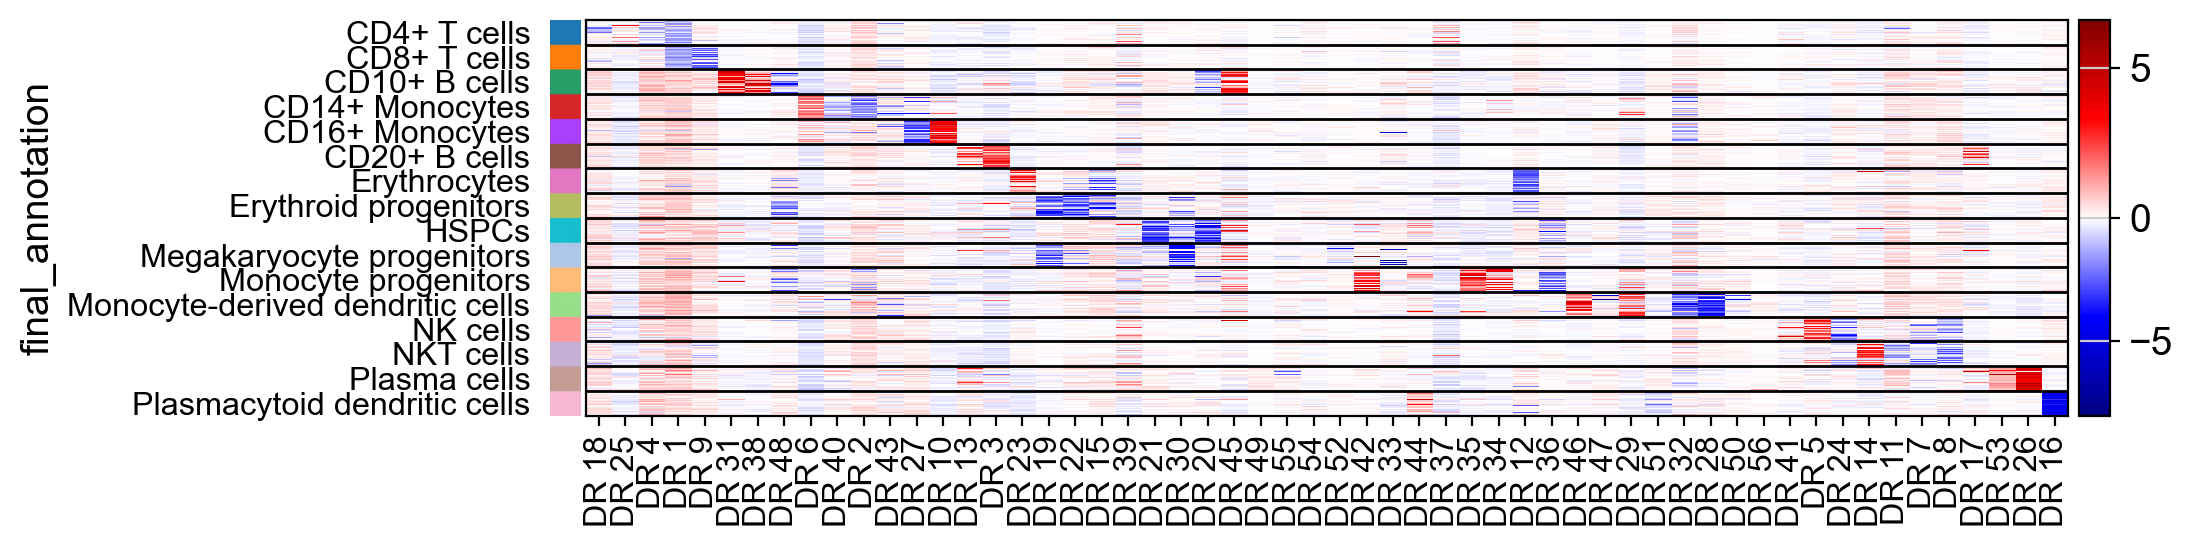

In [13]:
drvi.utils.pl.plot_latent_dims_in_heatmap(embed, annot_col, title_col="title", sort_by_categorical=True)

Some factors show a clear one-to-one relationship with a cell type. Let's identify them.

### Compute SMI and keep the strong matches

In [14]:
embed_directional_df = build_directional_df(embed)
smi_similarity, smi_top_matches = smi_matches(embed_directional_df, embed.obs[annot_col], smi_threshold)

print(f"SMI matrix shape: {smi_similarity.shape} (factor-directions x cell types)")
print(f"Factor-cell type pairs with SMI >= {smi_threshold}: {len(smi_top_matches)}")
smi_top_matches

SMI matrix shape: (111, 16) (factor-directions x cell types)
Factor-cell type pairs with SMI >= 0.7: 13


,title,variable,value
12,DR 16-,Plasmacytoid dendritic cells,0.930438
4,DR 10+,CD16+ Monocytes,0.914366
10,DR 26+,Plasma cells,0.907092
5,DR 3+,CD20+ B cells,0.892821
11,DR 53+,Plasma cells,0.833659
1,DR 31+,CD10+ B cells,0.814008
9,DR 28-,Monocyte-derived dendritic cells,0.813546
3,DR 2-,CD14+ Monocytes,0.809751
2,DR 6+,CD14+ Monocytes,0.768717
0,DR 38+,CD10+ B cells,0.744930


### Visualize the matches as a network

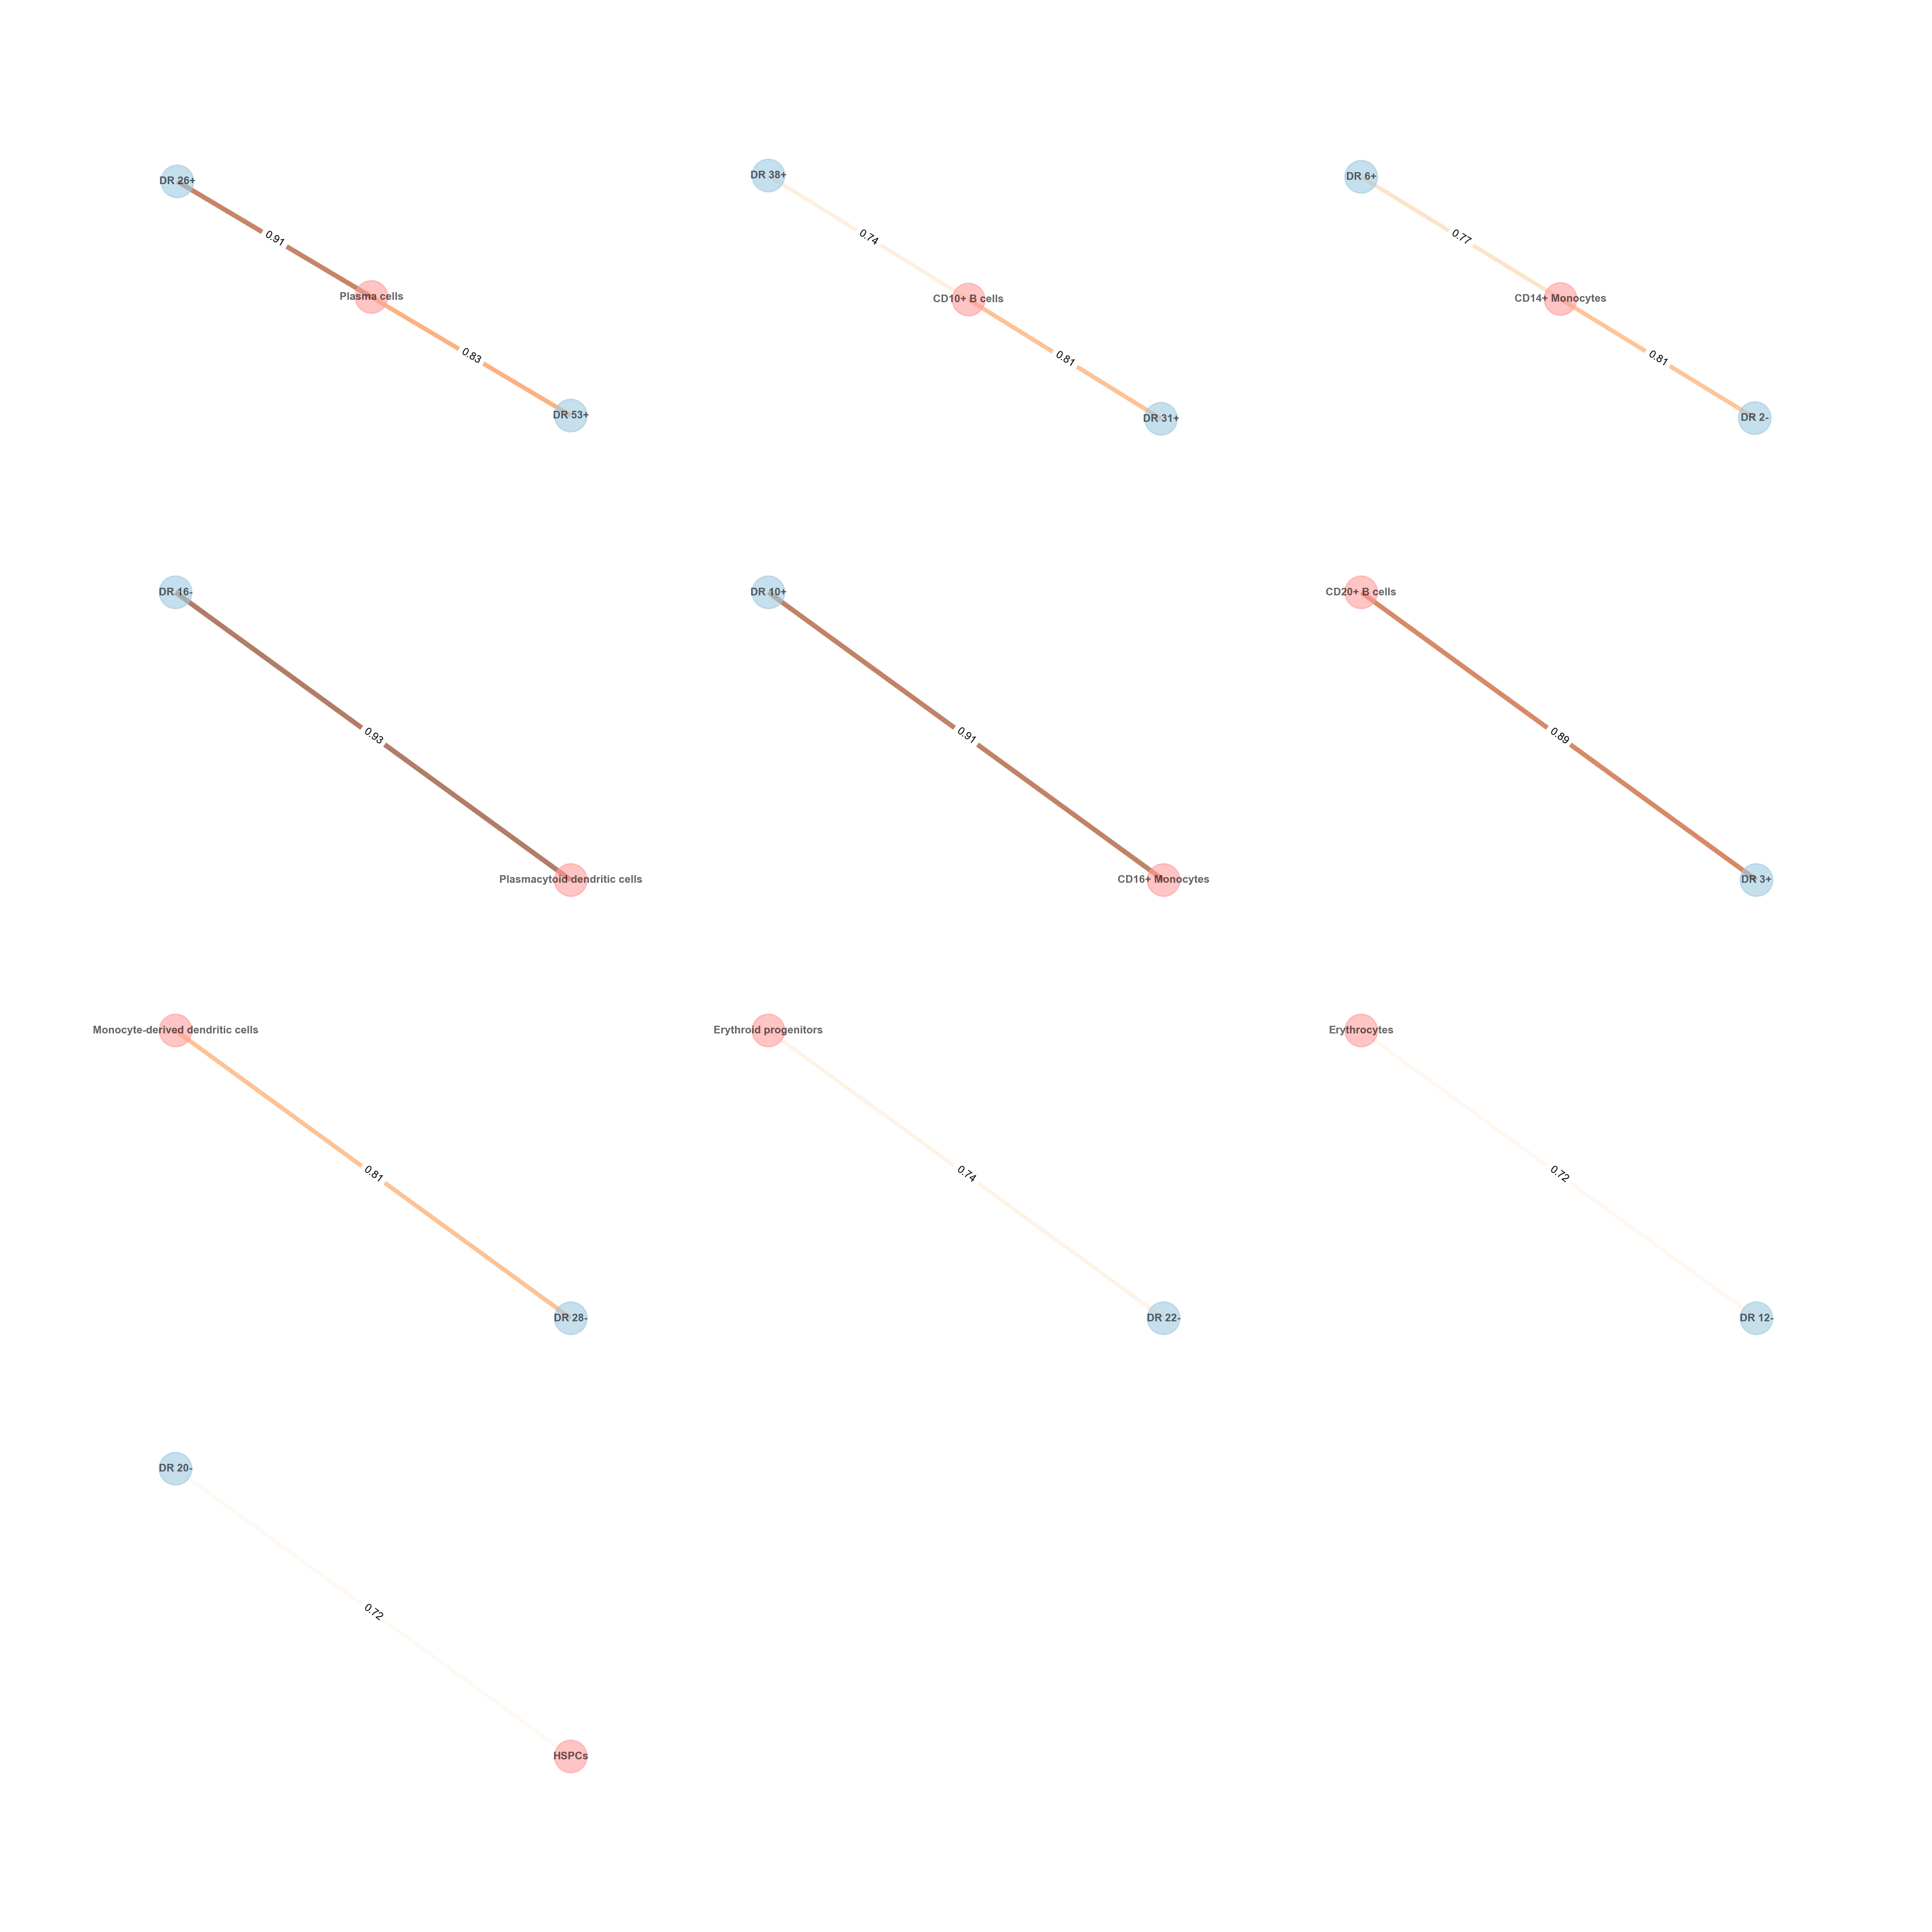

In [15]:
plot_packed_network(smi_top_matches, figsize=(20, 20))

### Store results

In [16]:
store_matches(embed, smi_top_matches, suffix="user_annotations")
(
    embed.var["positive_direction_match_with_user_annotations"].dropna().unique(),
    embed.var["negative_direction_match_with_user_annotations"].dropna().unique(),
)

(array(['Plasma cells', 'CD16+ Monocytes', 'CD14+ Monocytes',
        'CD20+ B cells', 'CD10+ B cells'], dtype=object),
 array(['HSPCs', 'Erythrocytes', 'Monocyte-derived dendritic cells',
        'CD14+ Monocytes', 'Plasmacytoid dendritic cells',
        'Erythroid progenitors'], dtype=object))

**How to read this.** Each row is a factor-direction mapped to an annotated cell type (e.g. in
the immune atlas, a plasmacytoid-DC factor, a CD16+ monocyte factor, a plasma-cell factor).
These matches let us label factors with the cell types we already recognize in the data.
Unmatched factors are the ones the remaining notebooks aim to characterize.

## 2. Cell types from a pre-trained model

When you have no manual labels (or want finer subtypes), you can borrow labels from any model
already trained on annotated atlases. **In this example we use
[CellTypist](https://www.celltypist.org/)**, a logistic-regression classifier — but any
annotation source plugs in the same way. We run it on the data, then compute SMI between its
labels and the DRVI factors, reusing exactly the helpers from Section 1.

Useful when you have **no manual labels**, or want **finer subtypes** than your labels provide.
**Skip it if your annotations are already sufficient.**

### Config

In [17]:
import celltypist

smi_threshold = 0.7

# CellTypist model. Run celltypist.models.models_description() to list options, and pick one
# matching your tissue/species. print(ct_model.cell_types) shows a model's cell types.
ct_model = "Immune_All_Low.pkl"  # e.g. "Developing_Mouse_Brain.pkl"

### Annotate cells with CellTypist

CellTypist expects normalized, log1p data over the **full** gene set, so we load the full-gene
AnnData. `majority_voting=True` refines per-cell labels within kNN neighborhoods (reduces noise).

In [18]:
raw_data_path = io_dir.parent / "immune_all.h5ad"
adata_full = sc.read_h5ad(raw_data_path)

adata_full.X = adata_full.layers["counts"].copy()
sc.pp.normalize_total(adata_full, target_sum=1e4)
sc.pp.log1p(adata_full)

celltypist.models.download_models(force_update=False, model=ct_model)
ct_model = celltypist.models.Model.load(model=ct_model)

predictions = celltypist.annotate(adata_full, model=ct_model, majority_voting=True)

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json


📚 Total models in list: 61


📂 Storing models in /Users/amir/.celltypist/data/models


💾 Total models to download: 1


💾 Downloading model [1/1]: Immune_All_Low.pkl


...

✅ Prediction done!


👀 Can not detect a neighborhood graph, will construct one before the over-clustering


⛓️ Over-clustering input data with resolution set to 15


🗳️ Majority voting the predictions


✅ Majority voting done!


In [19]:
# Attach CellTypist outputs to the latent AnnData.
embed.obs["celltypist_labels"] = predictions.predicted_labels["predicted_labels"].loc[embed.obs.index]
embed.obs["celltypist_majority"] = predictions.predicted_labels["majority_voting"].loc[embed.obs.index]

annot_col = "celltypist_majority"

### Visualize the factor x cell-type relationship

... storing 'positive_direction_match_with_user_annotations' as categorical


... storing 'negative_direction_match_with_user_annotations' as categorical


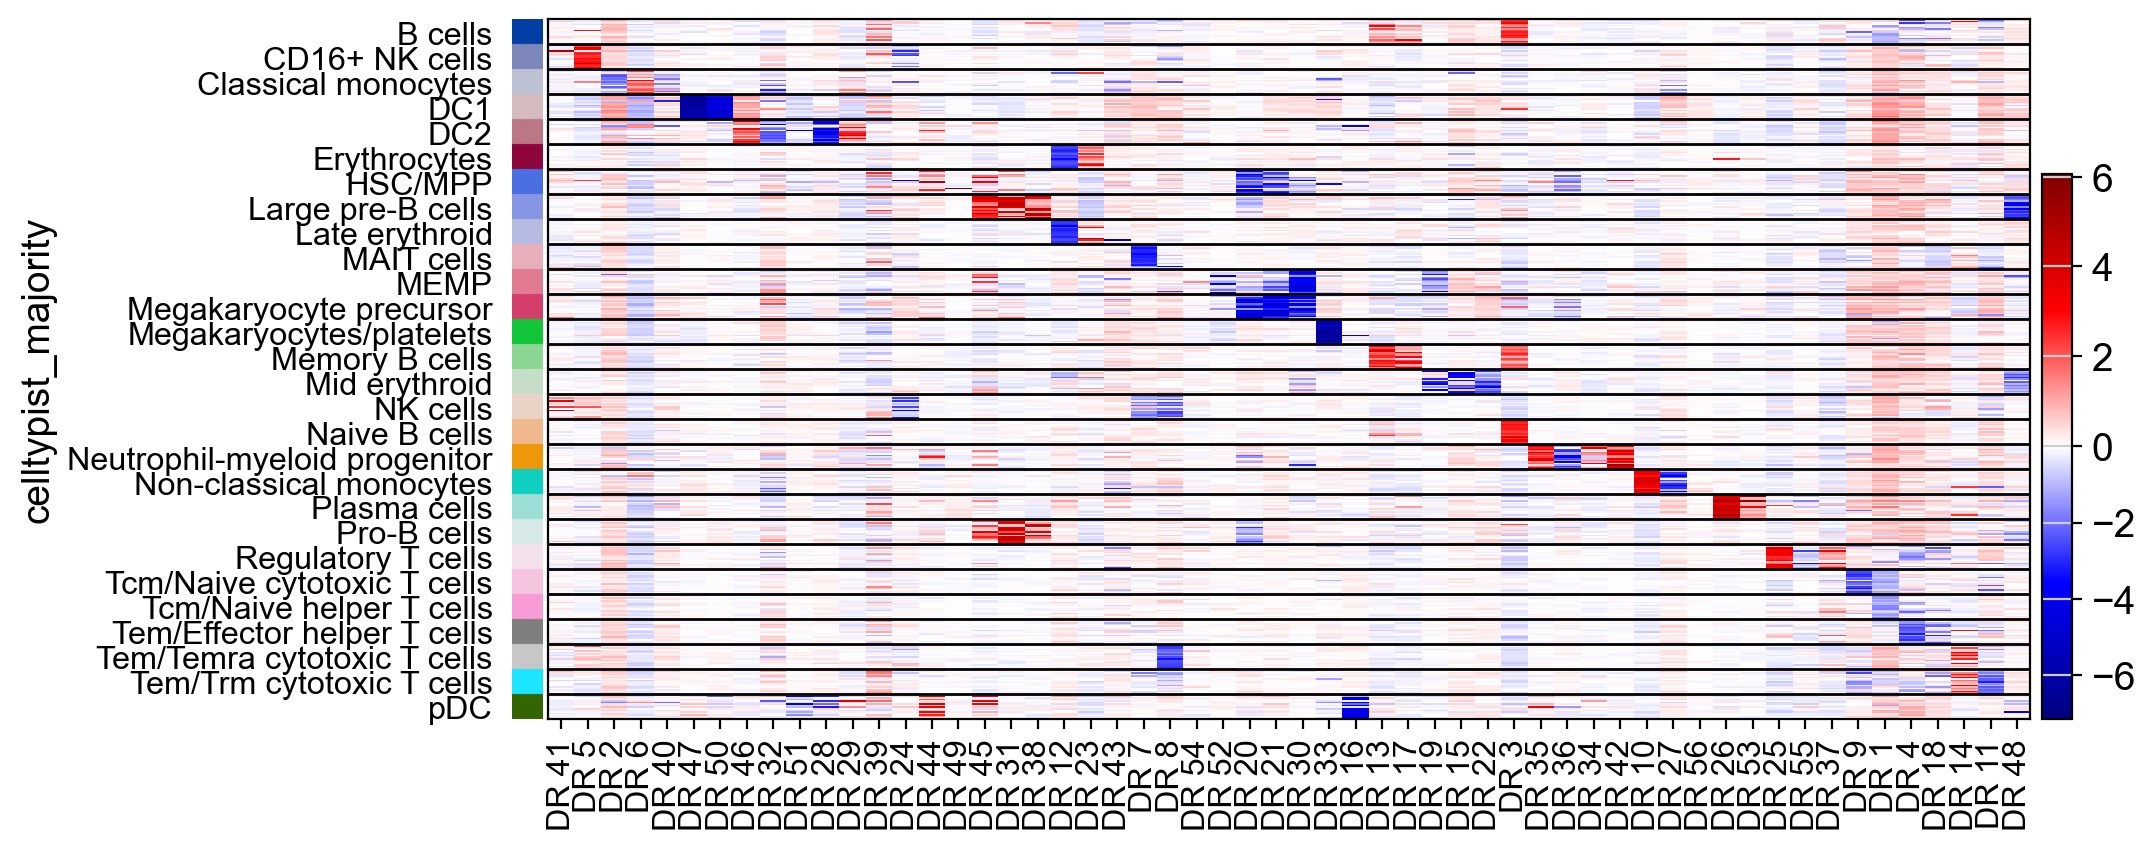

In [20]:
drvi.utils.pl.plot_latent_dims_in_heatmap(embed, annot_col, title_col="title", sort_by_categorical=True)

### Compute SMI and keep the strong matches

In [21]:
embed_directional_df = build_directional_df(embed)
smi_similarity, smi_top_matches = smi_matches(embed_directional_df, embed.obs[annot_col], smi_threshold)

print(f"Factor-cell type pairs with SMI >= {smi_threshold}: {len(smi_top_matches)}")
smi_top_matches

Factor-cell type pairs with SMI >= 0.7: 24


,title,variable,value
20,DR 26+,Plasma cells,0.962218
19,DR 10+,Non-classical monocytes,0.944466
11,DR 33-,Megakaryocytes/platelets,0.926782
15,DR 22-,Mid erythroid,0.899739
2,DR 47-,DC1,0.872397
17,DR 42+,Neutrophil-myeloid progenitor,0.851538
10,DR 30-,MEMP,0.848313
16,DR 3+,Naive B cells,0.845820
21,DR 53+,Plasma cells,0.840404
0,DR 5+,CD16+ NK cells,0.840213


### Visualize the matches as a network

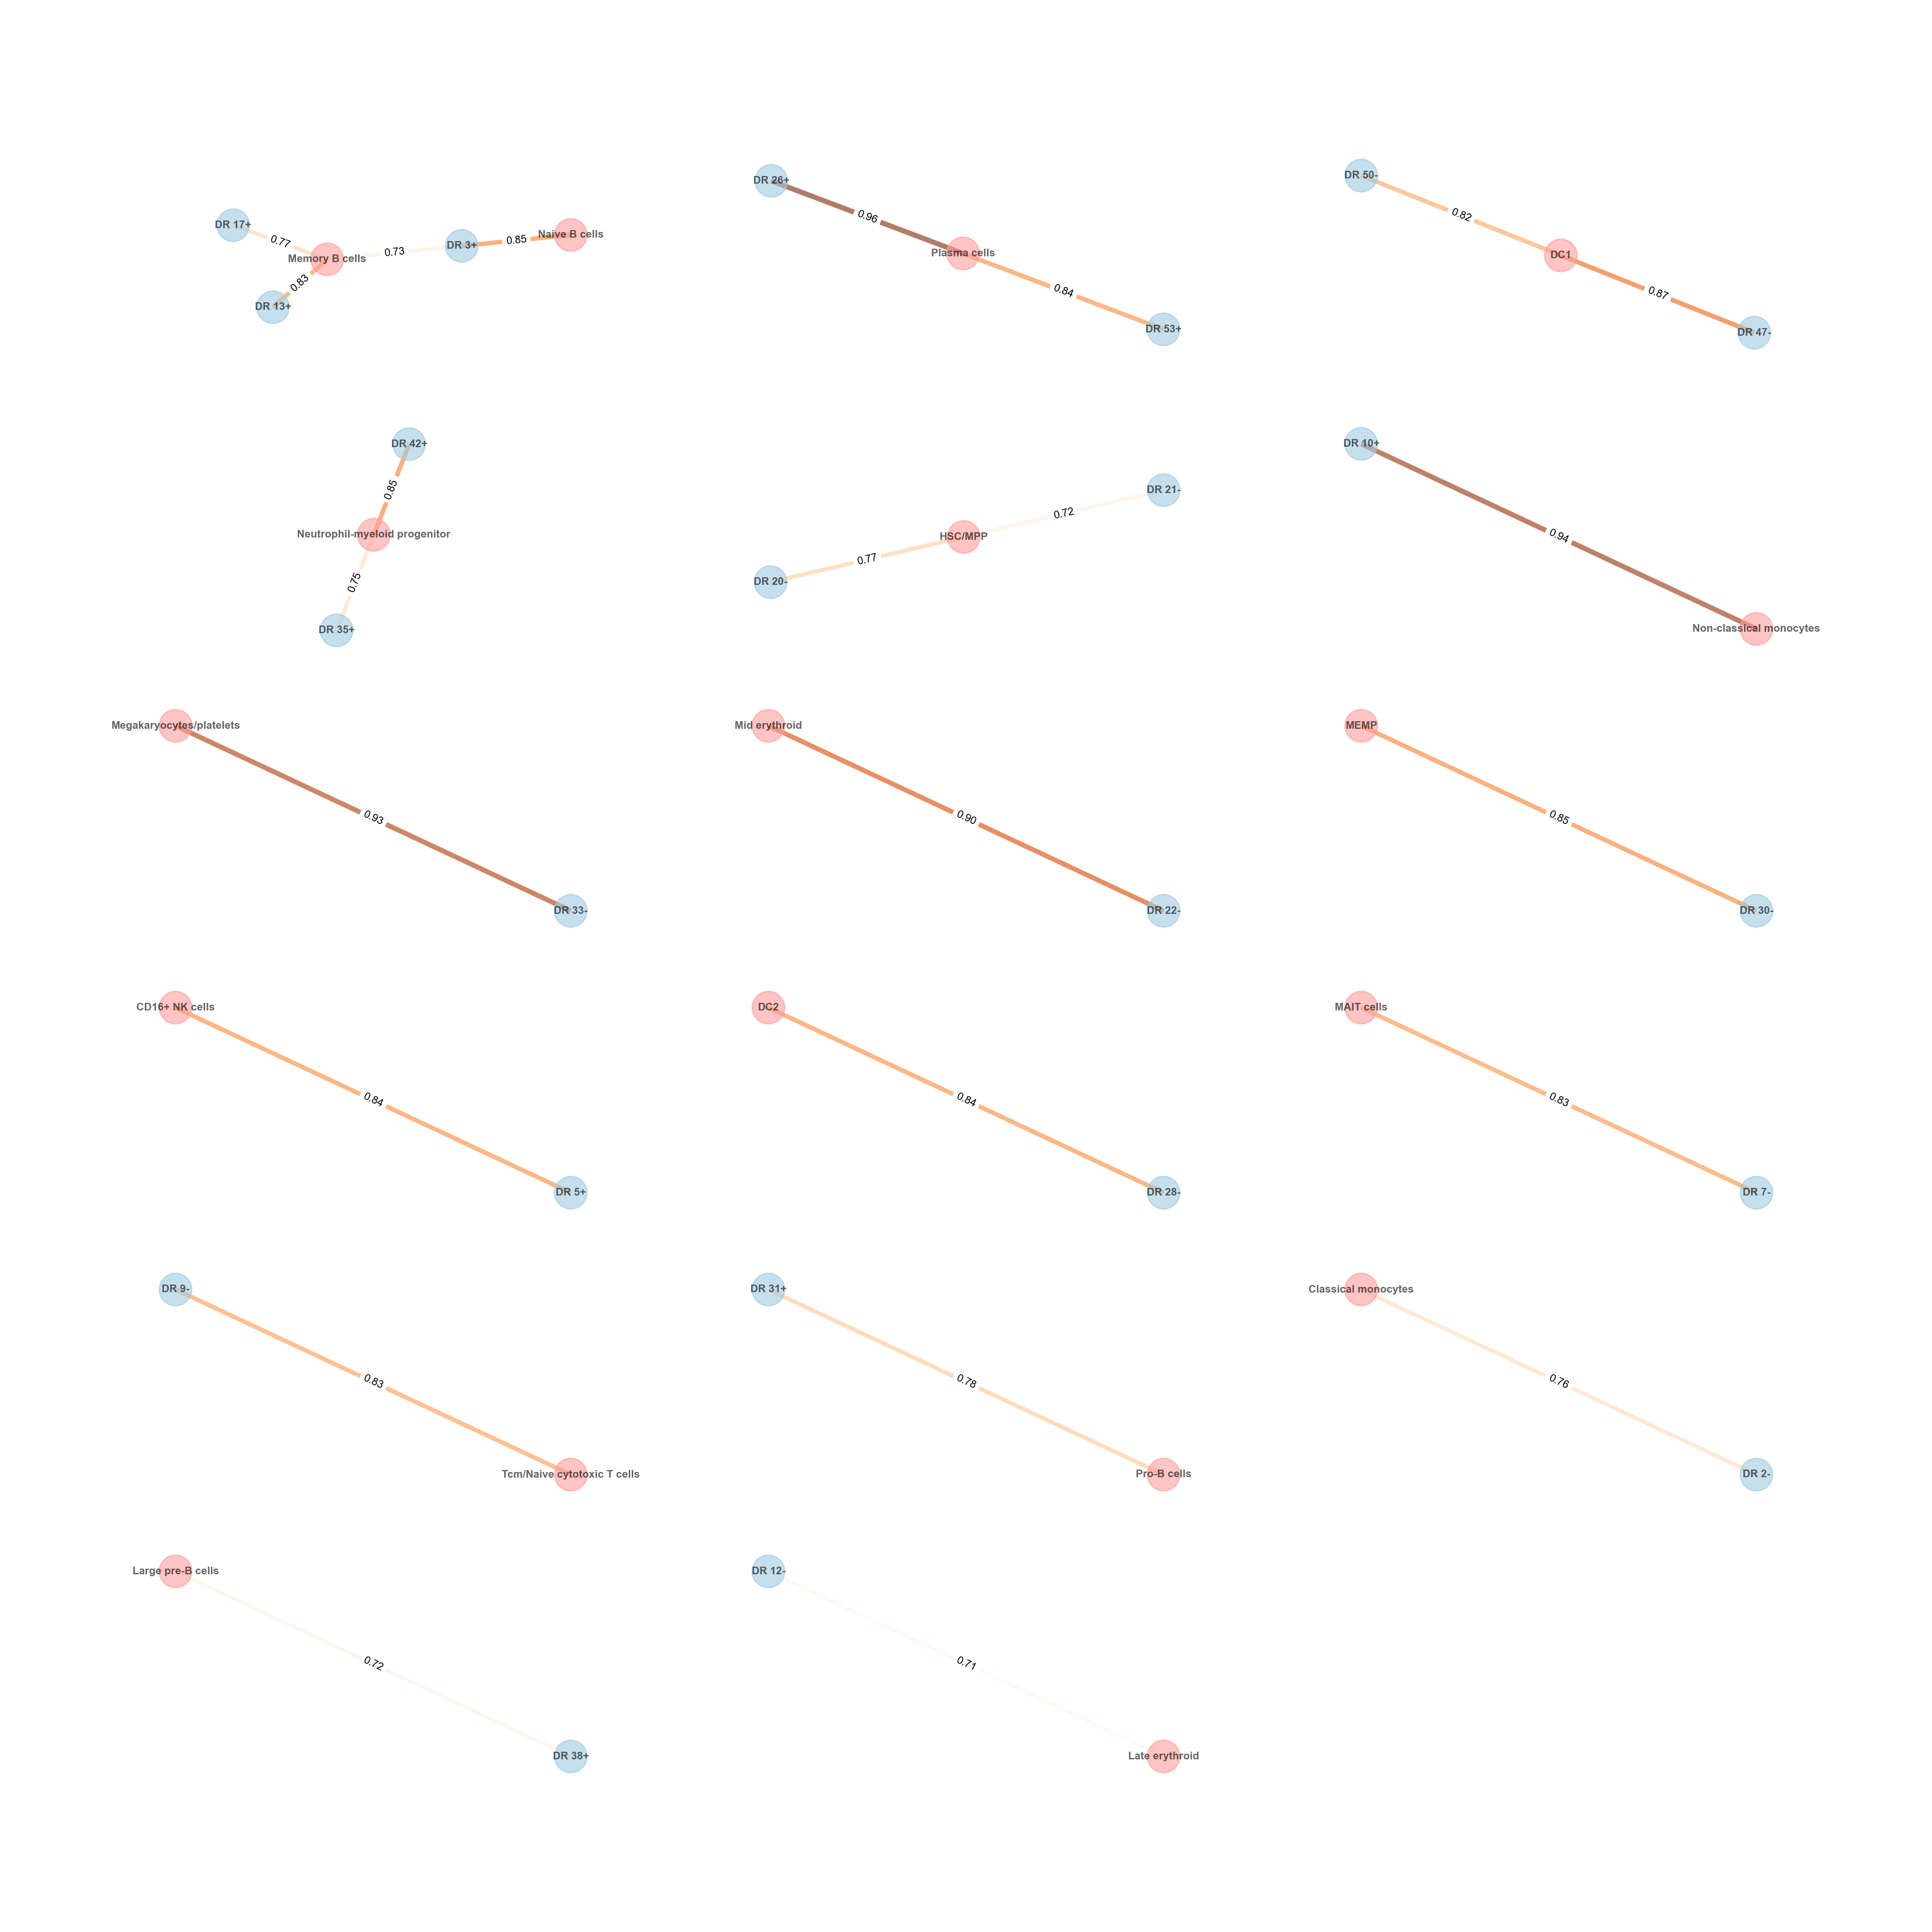

In [22]:
plot_packed_network(smi_top_matches, figsize=(20, 20))

### Store results

In [23]:
store_matches(embed, smi_top_matches, suffix="celltypist")
(
    embed.var["positive_direction_match_with_celltypist"].dropna().unique(),
    embed.var["negative_direction_match_with_celltypist"].dropna().unique(),
)

(array(['Neutrophil-myeloid progenitor', 'Plasma cells',
        'Non-classical monocytes', 'Memory B cells', 'Naive B cells',
        'Large pre-B cells', 'CD16+ NK cells', 'Pro-B cells'], dtype=object),
 array(['Megakaryocytes/platelets', 'DC1', 'Tcm/Naive cytotoxic T cells',
        'HSC/MPP', 'Late erythroid', 'MAIT cells', 'DC2',
        'Classical monocytes', 'MEMP', 'Mid erythroid'], dtype=object))

**How to read this.** A classifier can extend or replace manual labels: it may resolve finer
subtypes (e.g. naive vs. memory B cells, classical vs. non-classical monocytes) and can annotate
factors that had no prior label. We suggest verifying these assignments against each factor's
top-scoring genes. Note that, because DRVI is trained independently, errors from these
classifiers do not leak into the DRVI factors.

## 3. Save

Write the annotated embedding back to disk so the other notebooks (and the curation step in the
biological-processes notebook) can pick these results up.

In [24]:
import anndata as ad

ad.settings.allow_write_nullable_strings = True
embed.write_h5ad(embed_path)
print(f"Updated embedding saved to: {embed_path}")

... storing 'positive_direction_match_with_user_annotations' as categorical


... storing 'negative_direction_match_with_user_annotations' as categorical


... storing 'positive_direction_match_with_celltypist' as categorical


... storing 'negative_direction_match_with_celltypist' as categorical


Updated embedding saved to: /Users/amir/projects/drvi_tutorials/tmp_io/drvi_immune_128/embed.h5ad
